In [52]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import pink

from sparcl.client import SparclClient
from lmfit.models import Model, LinearModel
from lmfit.models import GaussianModel, LorentzianModel
from scipy.integrate import trapezoid

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"legend.frameon":False})

### data loading

In [ ]:
path = "data/query_results_from_dr1_agnqso.csv"

results = pd.read_csv(path,index_col=0)
results

,targetid,z,zerr,zwarn,civ_1549_flux,civ_1549_flux_ivar,civ_1549_sigma,flux_w3,flux_ivar_w3,spectype,survey
0,39633221419275546,2.440016,0.000635,0,208.402770,0.020173,3418.65480,19.313930,0.002920,QSO,main
1,39633217375964718,2.117797,0.000656,0,110.908840,0.012570,3048.58330,8.500388,0.003168,QSO,main
2,39633217375961604,2.189153,0.000326,0,43.242090,0.070611,597.65550,13.696554,0.002910,QSO,main
3,39633221419271454,2.320267,0.000859,0,233.598630,0.013143,4489.66750,2.761181,0.003186,QSO,main
4,39633221419271778,2.218200,0.000769,0,100.735690,0.016395,3171.20200,-81.434450,0.003246,QSO,main
...,...,...,...,...,...,...,...,...,...,...,...
532230,39633158747983618,2.327047,0.000193,0,210.939650,0.032602,1647.80700,-55.228440,0.002901,QSO,main
532231,39633158747985967,2.392584,0.000163,0,888.902300,0.013076,2714.59160,57.523330,0.003068,QSO,main
532232,39633158747983695,2.770790,0.000210,0,59.914715,0.108804,818.77783,-5.375127,0.002865,QSO,main
532233,39633158752174909,2.109610,0.000269,0,352.783540,0.016585,1963.30530,18.227741,0.002832,QSO,main


In [3]:
client = SparclClient()

idxs = results["targetid"].to_list()

idxs = [int(x) for x in idxs]

output_fields = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary','survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']

spectra = client.retrieve_by_specid(specid_list=idxs[:50], include=output_fields,dataset_list=["DESI-DR1"])

spectra_df = pd.DataFrame(spectra.data[1:])
# spectra_df

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [50]:
spectra_df

,specprimary,data_release,redshift,spectype,redshift_warning,targetid,specid,desi_target,survey,flux,wavelength,_dr
0,True,DESI-DR1,2.117797,QSO,0,39633217375964718,39633217375964718,3622,main,"[3.0574047565460205, -4.14963960647583, 3.7412...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,True,DESI-DR1,1.675163,GALAXY,0,39633221415078425,39633221415078425,4611686018427388932,main,"[7.159254550933838, 2.400733709335327, 3.90905...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,True,DESI-DR1,2.320267,QSO,0,39633221419271454,39633221419271454,4611686018427391526,main,"[-0.18166252970695496, 2.3862175941467285, 0.5...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
3,True,DESI-DR1,2.067840,QSO,0,39633221419271469,39633221419271469,4611686018427388932,main,"[0.33395111560821533, 2.2995874881744385, 1.32...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
4,True,DESI-DR1,2.218200,QSO,0,39633221419271778,39633221419271778,1028,main,"[-0.7639241814613342, -0.15702399611473083, -1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
5,True,DESI-DR1,3.133980,QSO,0,39633225445804676,39633225445804676,1028,main,"[-0.10278037935495377, 2.112659454345703, -3.1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
6,True,DESI-DR1,2.440016,QSO,0,39633221419275546,39633221419275546,4611686018427391526,main,"[0.9594663977622986, -1.0690971612930298, -1.2...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
7,True,DESI-DR1,2.770696,QSO,0,39633221423466972,39633221423466972,4611686018427388932,main,"[4.308331489562988, -0.5680516958236694, 7.365...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
8,True,DESI-DR1,2.557349,QSO,0,39633233431757463,39633233431757463,4611686018427388932,main,"[0.6271422505378723, -4.460757732391357, 2.809...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
9,True,DESI-DR1,2.811097,QSO,0,39633233431760663,39633233431760663,3622,main,"[-1.6403067111968994, -2.3595218658447266, -3....","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


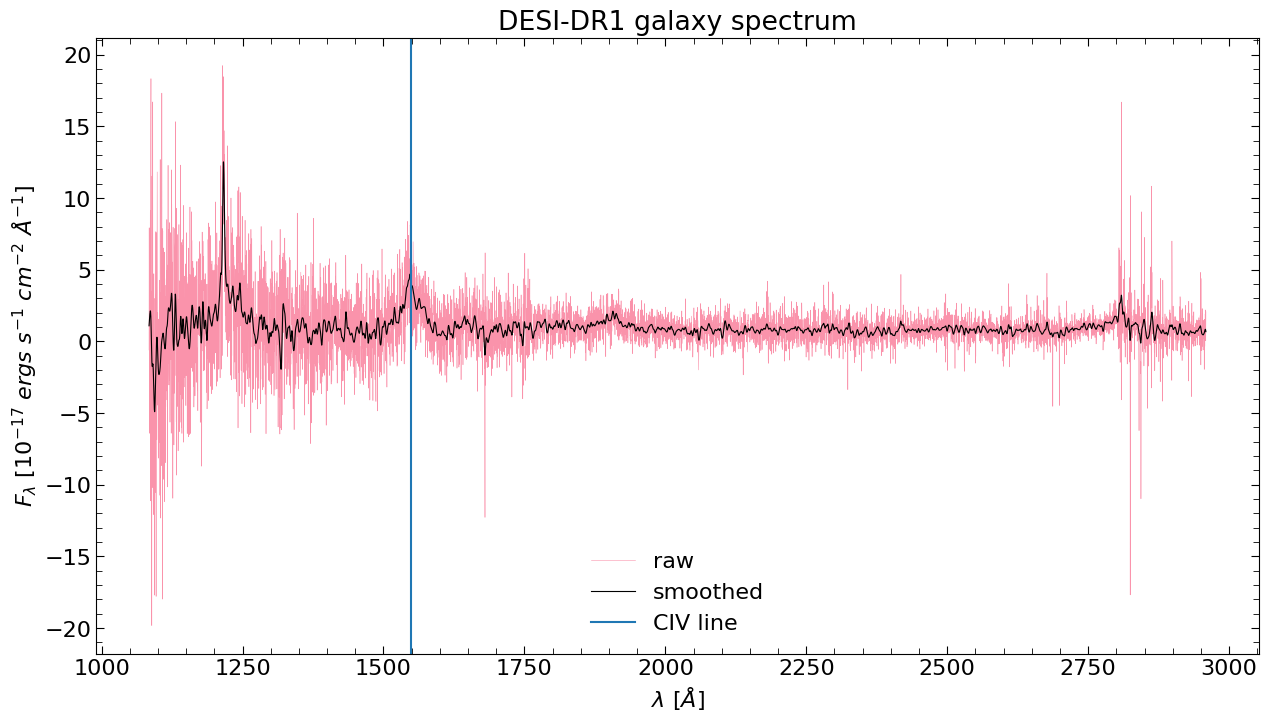

In [4]:
idx = 2


lam = spectra_df["wavelength"][idx]
flux = spectra_df["flux"][idx]
z = spectra_df["redshift"][idx]

lam, flux = adjust_redshift(lam, flux, z)

plot_spectrum(lam, flux, line_lambda=1548, line_label="CIV line")

### lmfit

In [21]:
## cut to CIV relevant section
lower_lim, upper_lim = 1450, 1650  # establish limits

lam_subset, flux_subset = [], []

# cut lists
for i in range(len(lam)):
    if lam[i] >= lower_lim and lam[i] <= upper_lim:
        lam_subset.append(lam[i])
        flux_subset.append(flux[i])

flux_subset = convolve(flux_subset, Gaussian1DKernel(5))

assert len(lam_subset) == len(flux_subset)  # sanity check

In [ ]:
gaussian1 = GaussianModel()
background = LinearModel()
model = gaussian1 + background

# check which params need to be specified
print('parameter names: {}'.format(model.param_names))
print('independent variables: {}'.format(model.independent_vars))

parameter names: ['amplitude', 'center', 'sigma', 'slope', 'intercept']
independent variables: ['x']


In [23]:
result = model.fit(flux_subset, x=lam_subset, amplitude=5, center=1548, sigma=15, slope=0, intercept=1)

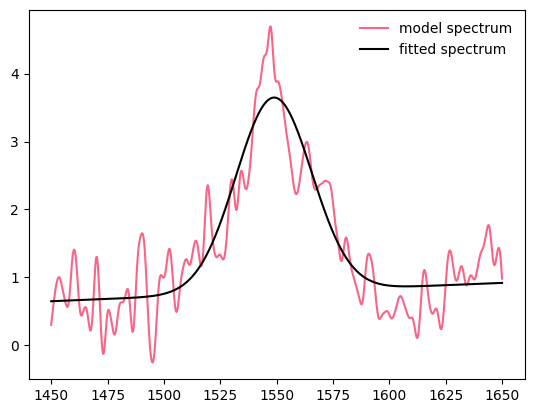

In [54]:
y_fit = result.best_fit #the simulated intensity

result.best_values #the extracted peak parameters

# Comparison of the fitted spectrum with the original one
plt.plot(lam_subset, flux_subset,label='model spectrum',color=pink)
plt.plot(lam_subset, y_fit, label='fitted spectrum',color="black")
plt.legend()

plt.show()

In [51]:
trapezoid(y_fit,lam_subset)

277.09294165576887